Carregando os dados...

Treinando o modelo de Regressão Linear...

--- RESULTADOS FINANCEIROS DO MODELO ---
MAE (Erro Médio Absoluto):  $ 1.78
RMSE (Raiz do Erro Quad.):  $ 2.52
R² (Determinação):          0.9274
R² Ajustado:                0.9274

--- O QUANTO CADA VARIÁVEL INFLUENCIA NO PREÇO ---
NOTA: Como os dados foram padronizados (StandardScaler), os valores abaixo indicam
o aumento/redução no preço em Dólares ($) para cada aumento de 1 Desvio Padrão na variável.
         Variável  Impacto (Coeficiente)
name_Lux Black XL               3.676082
    name_UberPool              -3.305654
      name_Shared              -3.284173
         distance               3.174316
       name_UberX              -3.016340
         name_WAV              -3.015836
   name_Black SUV               2.743932
        name_Lyft              -2.507808
 surge_multiplier               1.745543
      name_UberXL              -1.357717
    cab_type_Uber               1.193043
   name_Lux Black               1

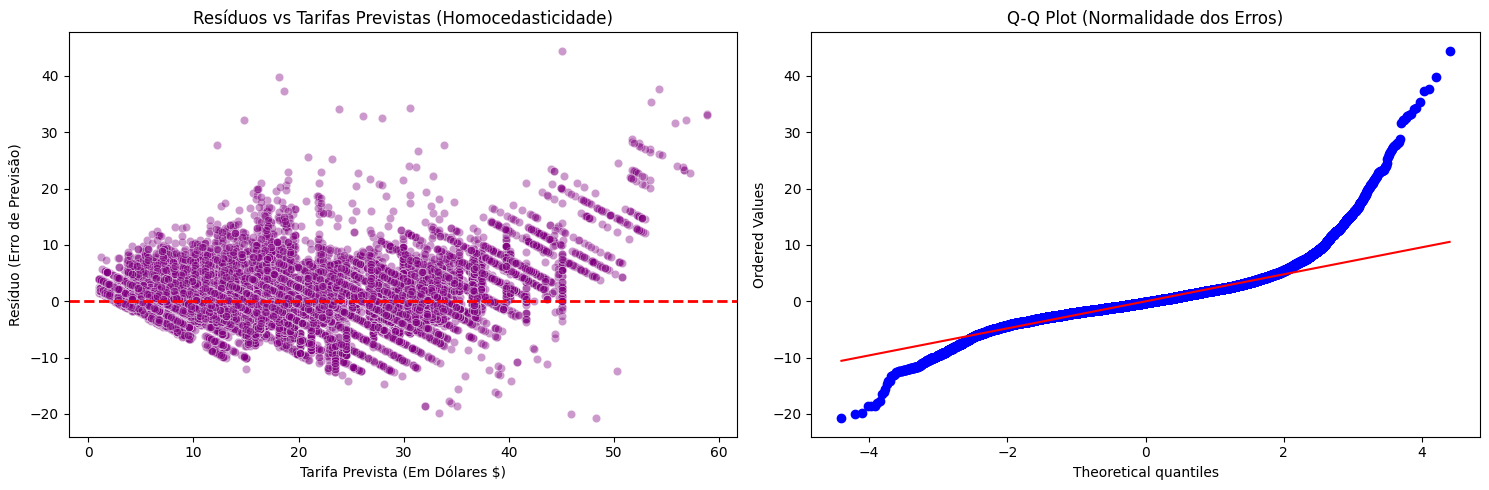

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==============================================================================
# 1. Carregamento dos Dados
# ==============================================================================
# Certifique-se de que o arquivo CSV do Kaggle está no seu ambiente do Colab
print("Carregando os dados...")
df = pd.read_csv('rideshare_kaggle.csv')

# ==============================================================================
# 2. Seleção de Colunas e Limpeza
# ==============================================================================
# Selecionamos as variáveis mais lógicas para o preço e removemos corridas sem tarifa final calculada
colunas_interesse = ['price', 'distance', 'surge_multiplier', 'cab_type', 'name']
df = df[colunas_interesse].dropna(subset=['price'])

# Separando as variáveis independentes (X) do alvo (y)
X = df.drop(columns=['price'])
y = df['price']

# ==============================================================================
# 3. Engenharia de Atributos (Transformando Texto em Números)
# ==============================================================================
# Transforma as categorias de texto (Uber, Lyft, SUV, Black) em colunas de 0 e 1
X_encoded = pd.get_dummies(X, drop_first=True)
# Converte valores booleanos True/False para 1.0/0.0 para evitar problemas matemáticos
X_encoded = X_encoded.astype(float)

# ==============================================================================
# 4. Divisão (Treino/Teste) e Padronização
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Colocando todas as colunas na mesma escala para que possamos comparar o "peso" dos coeficientes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================================================
# 5. Treinamento do Modelo
# ==============================================================================
print("\nTreinando o modelo de Regressão Linear...")
modelo_ols = LinearRegression()
modelo_ols.fit(X_train_scaled, y_train)

# ==============================================================================
# 6. Previsões e Métricas de Erro
# ==============================================================================
y_pred = modelo_ols.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Cálculo manual e seguro do R² Ajustado
n = X_test_scaled.shape[0] # Número de observações no teste
p = X_test_scaled.shape[1] # Número de colunas preditoras
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n--- RESULTADOS FINANCEIROS DO MODELO ---")
print(f"MAE (Erro Médio Absoluto):  $ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quad.):  $ {rmse:.2f}")
print(f"R² (Determinação):          {r2:.4f}")
print(f"R² Ajustado:                {r2_ajustado:.4f}\n")

# ==============================================================================
# 7. ANÁLISE DE INFLUÊNCIA (RANKING DE COEFICIENTES)
# ==============================================================================
print("--- O QUANTO CADA VARIÁVEL INFLUENCIA NO PREÇO ---")
# Criando um DataFrame com os nomes das colunas e os pesos matemáticos do modelo
coeficientes = pd.DataFrame({
    'Variável': X_encoded.columns,
    'Impacto (Coeficiente)': modelo_ols.coef_
})

# Calculando o impacto absoluto para classificar do mais importante para o menos importante
coeficientes['Impacto Absoluto'] = coeficientes['Impacto (Coeficiente)'].abs()
coeficientes = coeficientes.sort_values(by='Impacto Absoluto', ascending=False).drop(columns=['Impacto Absoluto'])

print("NOTA: Como os dados foram padronizados (StandardScaler), os valores abaixo indicam")
print("o aumento/redução no preço em Dólares ($) para cada aumento de 1 Desvio Padrão na variável.")
print(coeficientes.to_string(index=False))

# ==============================================================================
# 8. Gráficos de Diagnóstico (Homocedasticidade e Normalidade)
# ==============================================================================
residuos = y_test - y_pred

# Configurando a imagem como as que você enviou anteriormente
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: O Funil (Homocedasticidade)
sns.scatterplot(x=y_pred, y=residuos, ax=axes[0], color='purple', alpha=0.4)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Resíduos vs Tarifas Previstas (Homocedasticidade)')
axes[0].set_xlabel('Tarifa Prevista (Em Dólares $)')
axes[0].set_ylabel('Resíduo (Erro de Previsão)')

# Gráfico 2: Desvio na Cauda (Normalidade / Q-Q Plot)
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normalidade dos Erros)')

plt.tight_layout()
plt.show()